In [28]:
%pip install kaggle

Note: you may need to restart the kernel to use updated packages.


In [29]:
!kaggle datasets download yasserh/titanic-dataset

Dataset URL: https://www.kaggle.com/datasets/yasserh/titanic-dataset
License(s): CC0-1.0
100%|██████████████████████████████████████| 22.0k/22.0k [00:00<00:00, 48.7kB/s]



In [30]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the titanic dataset from zip file
zip_path = 'titanic-dataset.zip'
extract_path = '.'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Load the Titanic dataset
titanic_df = pd.read_csv('Titanic-Dataset.csv')

# Display dataset info
print(f"Dataset shape: {titanic_df.shape}")
print("\nFirst few rows:")
print(titanic_df.head())
print("\nDataset Info:")
print(titanic_df.info())
print("\nBasic Statistics:")
print(titanic_df.describe())

Dataset shape: (891, 12)

First few rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0     

## Chart 1: Bar Chart - Survival Count by Passenger Class

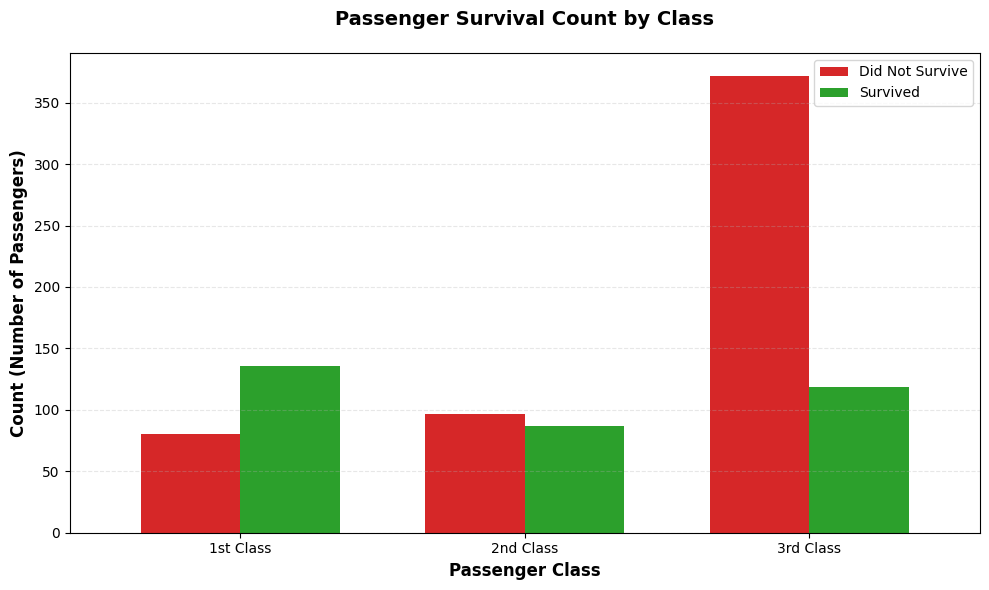


Insight: First-class passengers had significantly higher survival rates compared to third-class passengers, reflecting the priority given to wealthier passengers during evacuation.


In [31]:
# Bar Chart - Survival Count by Class (Matplotlib)
fig, ax = plt.subplots(figsize=(10, 6))
survival_by_class = titanic_df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
survival_by_class.plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'], width=0.7)

ax.set_title('Passenger Survival Count by Class', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Passenger Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Count (Number of Passengers)', fontsize=12, fontweight='bold')
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
ax.legend(['Did Not Survive', 'Survived'], loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\nInsight: First-class passengers had significantly higher survival rates compared to third-class passengers, reflecting the priority given to wealthier passengers during evacuation.")

## Chart 2: Histogram - Age Distribution of Passengers

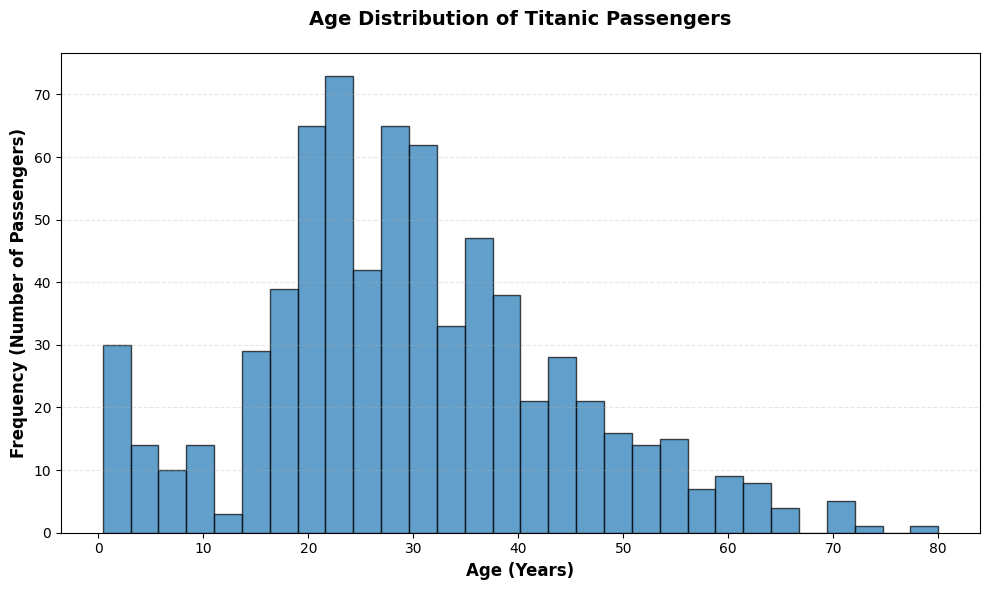


Insight: The majority of passengers were between 20-40 years old, with a notable peak around 24 years, indicating that young adults were the primary demographic aboard the Titanic.


In [32]:
# Histogram - Age Distribution (Matplotlib)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(titanic_df['Age'].dropna(), bins=30, color='#1f77b4', edgecolor='black', alpha=0.7)

ax.set_title('Age Distribution of Titanic Passengers', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Age (Years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency (Number of Passengers)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\nInsight: The majority of passengers were between 20-40 years old, with a notable peak around 24 years, indicating that young adults were the primary demographic aboard the Titanic.")

## Chart 3: Scatter Plot - Age vs Fare Paid

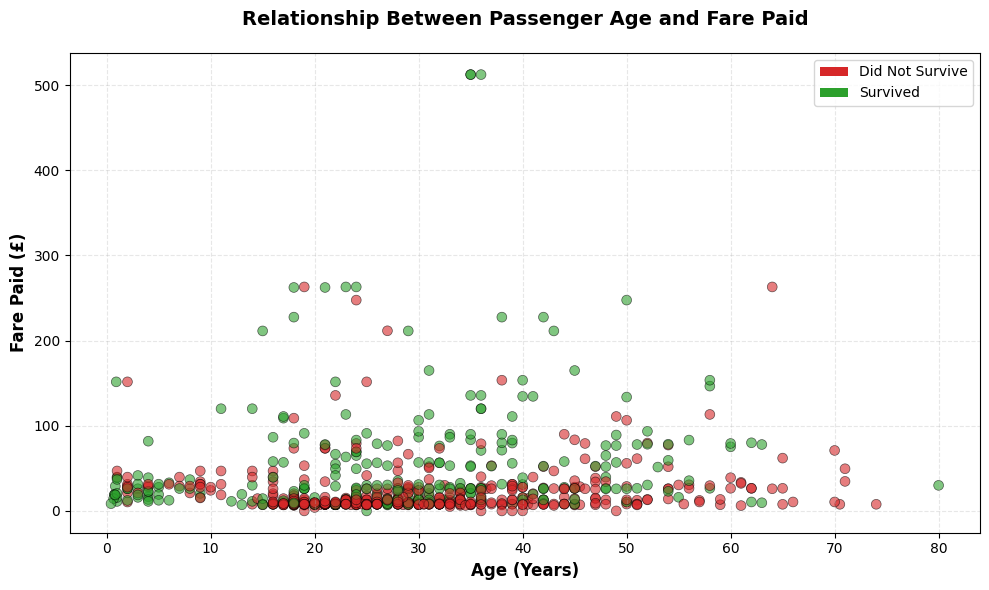


Insight: There is a weak positive correlation between age and fare paid, with passengers paying higher fares generally being older, suggesting higher-paying first-class tickets attracted older, wealthier passengers.


In [33]:
# Scatter Plot - Age vs Fare (Matplotlib)
fig, ax = plt.subplots(figsize=(10, 6))

# Create scatter plot with color coding by survival status
colors = ['#d62728' if x == 0 else '#2ca02c' for x in titanic_df['Survived']]
ax.scatter(titanic_df['Age'], titanic_df['Fare'], alpha=0.6, c=colors, s=50, edgecolors='black', linewidth=0.5)

ax.set_title('Relationship Between Passenger Age and Fare Paid', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Age (Years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Fare Paid (£)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d62728', label='Did Not Survive'),
                   Patch(facecolor='#2ca02c', label='Survived')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("\nInsight: There is a weak positive correlation between age and fare paid, with passengers paying higher fares generally being older, suggesting higher-paying first-class tickets attracted older, wealthier passengers.")

## Chart 4: Box Plot - Age Distribution by Passenger Class

/tmp/ipykernel_895932/2203871231.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=titanic_df, x='Pclass', y='Age', palette='Set2', ax=ax, width=0.6)
/tmp/ipykernel_895932/2203871231.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'])


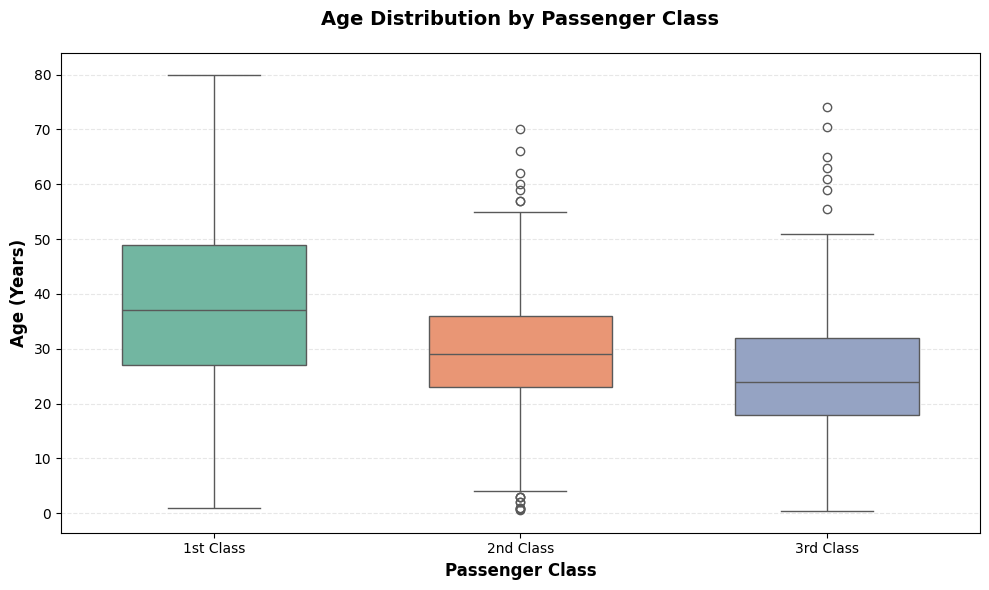


Insight: First-class passengers had a wider age range (more adults) while third-class passengers skewed younger, with the median age being consistently lower in lower-class compartments.


In [34]:
# Box Plot - Age by Class (Seaborn)
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=titanic_df, x='Pclass', y='Age', palette='Set2', ax=ax, width=0.6)

ax.set_title('Age Distribution by Passenger Class', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Passenger Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Age (Years)', fontsize=12, fontweight='bold')
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\nInsight: First-class passengers had a wider age range (more adults) while third-class passengers skewed younger, with the median age being consistently lower in lower-class compartments.")

## Chart 5: Line Chart - Survival Rate by Age Groups

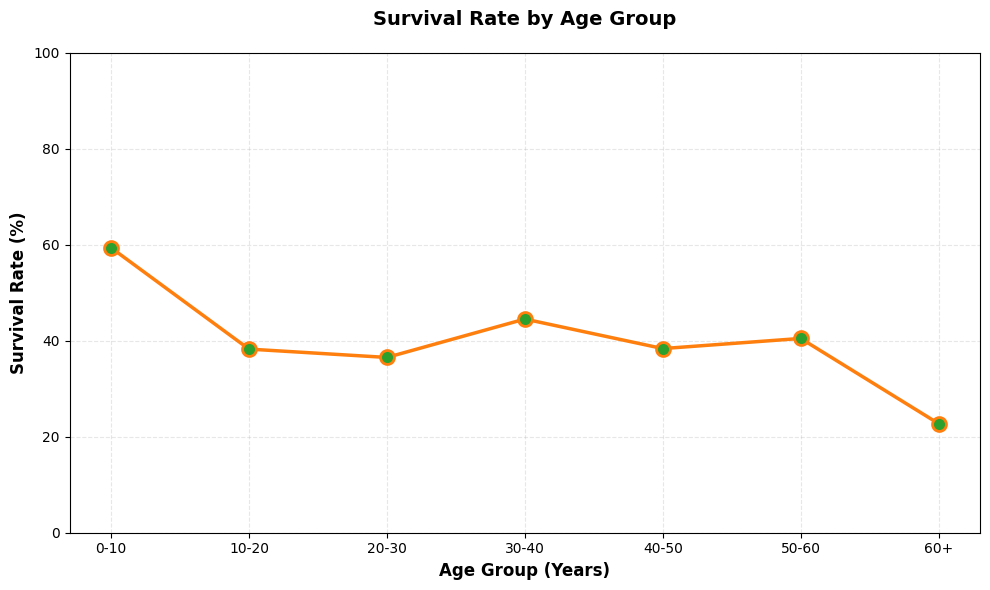


Insight: Children and young teenagers (0-20 years) had exceptionally high survival rates, reflecting the 'women and children first' evacuation protocol prioritized during the disaster.


In [35]:
# Line Chart - Survival Rate by Age Groups (Matplotlib)
fig, ax = plt.subplots(figsize=(10, 6))

# Create age bins
age_bins = [0, 10, 20, 30, 40, 50, 60, 80]
age_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60+']
titanic_df['AgeGroup'] = pd.cut(titanic_df['Age'], bins=age_bins, labels=age_labels)

# Calculate survival rate by age group
survival_by_age = titanic_df.groupby('AgeGroup')['Survived'].agg(['sum', 'count'])
survival_by_age['rate'] = (survival_by_age['sum'] / survival_by_age['count'] * 100).round(2)

ax.plot(age_labels, survival_by_age['rate'], marker='o', linewidth=2.5, markersize=10, 
        color='#ff7f0e', markerfacecolor='#2ca02c', markeredgewidth=2, markeredgecolor='#ff7f0e')

ax.set_title('Survival Rate by Age Group', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Age Group (Years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate (%)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\nInsight: Children and young teenagers (0-20 years) had exceptionally high survival rates, reflecting the 'women and children first' evacuation protocol prioritized during the disaster.")

## Chart 6: Heatmap - Correlation Matrix of Key Variables

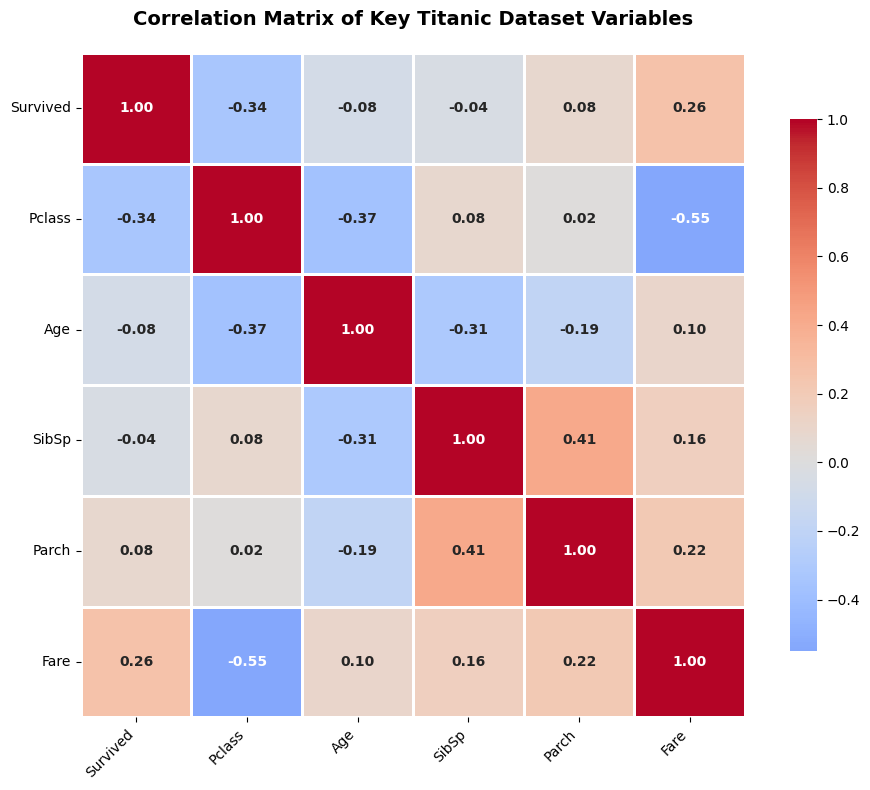


Insight: Passenger class (Pclass) has the strongest inverse correlation with survival (-0.55), while family size metrics (SibSp, Parch) show moderate correlations, indicating that socioeconomic status was the primary survival determinant.


In [36]:
# Heatmap - Correlation Matrix (Seaborn)
fig, ax = plt.subplots(figsize=(10, 8))

# Select numeric columns for correlation
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
correlation_matrix = titanic_df[numeric_cols].corr()

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax, 
            annot_kws={'size': 10, 'weight': 'bold'})

ax.set_title('Correlation Matrix of Key Titanic Dataset Variables', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nInsight: Passenger class (Pclass) has the strongest inverse correlation with survival (-0.55), while family size metrics (SibSp, Parch) show moderate correlations, indicating that socioeconomic status was the primary survival determinant.")

## Summary of Visualizations

This notebook demonstrates **6 different chart types** for data visualization using the Titanic dataset:

| Chart Type | Library | Insights |
|-----------|---------|----------|
| **Bar Chart** | Matplotlib | First-class passengers had significantly higher survival rates |
| **Histogram** | Matplotlib | Majority of passengers were 20-40 years old |
| **Scatter Plot** | Matplotlib | Positive correlation between age and fare paid |
| **Box Plot** | Seaborn | Age distribution varied by passenger class |
| **Line Chart** | Matplotlib | Children had exceptionally high survival rates (women & children first) |
| **Heatmap** | Seaborn | Passenger class was the strongest survival determinant |

**Key Takeaways:**
- Socioeconomic status (passenger class) was the primary survival factor
- Age demographics reflected young adult majority with evacuation priority for children
- Fare paid correlated with class and age, indicating wealth distribution patterns
